# Deep Learning for Malaria Detection Using Convolutional Neural Networks in PyTorch

**Student:** M N S Poojan Kumar, U00954242
**Dataset:** NIH Malaria Cell Images Dataset (National Institutes of Health, via Kaggle)
**Date:** April 2026

---

## Abstract

This study presents an automated malaria detection system using convolutional neural networks applied to microscope blood cell images. The NIH Malaria Cell Images Dataset, comprising 27,558 labelled images distributed equally between Parasitized and Uninfected classes, was used for training and evaluation. Five architectures were compared: a custom-designed CNN trained from scratch, and four transfer learning models employing ImageNet-pretrained weights, namely ResNet-18, VGG16, ResNet-50, and EfficientNet-B0. All models were trained using CrossEntropyLoss with the Adam optimiser, ReduceLROnPlateau scheduling, and early stopping. On the held-out test set of 2,756 images, EfficientNet-B0 and ResNet-50 achieved the highest accuracy of 97.79% and a ROC-AUC of 1.00. EfficientNet-B0 is identified as the optimal model for deployment, given its equivalent accuracy and significantly lower parameter count of approximately 5.3 million. The results demonstrate that deep learning can reliably automate malaria screening, with clinical implications for resource-limited healthcare settings.

---

## Contents

| Section | Description |
|---|---|
| 1. Environment Setup | Package installation, device configuration, seed initialisation |
| 2. Dataset Loading | Automated data acquisition via KaggleHub |
| 3. Exploratory Data Analysis | Class balance, sample inspection, dimension and intensity analysis |
| 4. Data Preprocessing | Transform pipelines and augmentation strategy |
| 5. Train, Validation, and Test Split | Reproducible 80/10/10 partition |
| 6. Model Architectures | All five CNN definitions in a unified section |
| 7. Loss Function and Optimiser | CrossEntropyLoss, Adam, and learning rate scheduling |
| 8. Training Strategy | Unified training loop with early stopping |
| 9. Model Training | Sequential training of all five architectures |
| 10. Evaluation | Classification reports, confusion matrices, Grad-CAM visualisation |
| 11. Discussion and Results Interpretation | Performance analysis and clinical interpretation |
| 12. Conclusion | Summary, best model recommendation, future directions |

---

## Ethical Considerations

This system is designed as a clinical decision-support tool. It is intended to assist qualified healthcare professionals, not to replace clinical judgement. All model predictions in a real deployment scenario must be reviewed by a trained clinician before any diagnostic or treatment decisions are made. The model was developed and evaluated exclusively on the NIH benchmark dataset; generalisation to images from different staining protocols, microscope types, or laboratory conditions has not been verified.

---

## Citations and Acknowledgements

- **Dataset:** NIH Malaria Cell Images Dataset. Kaggle contributor: iarunava. Source: National Institutes of Health.
- **Framework:** PyTorch (Paszke et al., NeurIPS 2019) and torchvision (Meta AI).
- **Pretrained weights:** ImageNet-1K via the torchvision model zoo.
- **Evaluation metrics:** scikit-learn (Pedregosa et al., JMLR 2011).
- **Explainability:** Grad-CAM (Selvaraju et al., ICCV 2017).
- **AI assistance:** Claude (Anthropic) provided assistance with code structure, markdown content, and report writing. All model architectures, training logic, and experimental results represent the original work of the student.

---

## How to Run This Notebook

### Recommended Environment
Google Colab with GPU acceleration is recommended. Enable GPU via: Runtime > Change runtime type > T4 GPU.

### Step 1: Install Dependencies
Cell 1a installs all required packages automatically. To install manually:
```
pip install torch torchvision kagglehub scikit-learn seaborn opencv-python matplotlib Pillow tqdm pandas
```

### Step 2: Kaggle Credentials (Local Environments Only)
When running outside Colab, place a valid `kaggle.json` API key in `~/.kaggle/`. KaggleHub manages credentials automatically within Colab.

### Step 3: Execute Cells in Order
Run all cells sequentially from top to bottom. Each section depends on outputs produced by preceding cells.

### Expected Results

| Model | Expected Test Accuracy |
|---|---|
| Custom CNN | 96.55% |
| ResNet-18 | 97.32% |
| VGG16 | 97.50% |
| ResNet-50 | 97.79% |
| EfficientNet-B0 | 97.79% |

The best model is saved as `malaria_best_model.pth` upon completion.

### Reproducibility
All experiments use `seed = 42`. Results are reproducible on identical hardware configurations.

## Section 1: Environment Setup

This section installs all required dependencies, configures the compute device (CPU or CUDA-enabled GPU), and sets the global random seed to ensure full experimental reproducibility.

The seed value of 42 is applied to Python's random module, NumPy, and PyTorch, including CUDA if a GPU is available. This guarantees that all random operations, including weight initialisation, data shuffling, and augmentation, produce consistent results across independent runs.

In [ ]:
# ── 1a. Install Dependencies ─────────────────────────────────────────────────
!pip install -q kagglehub[pandas-datasets]
!pip install -q torch torchvision torchaudio
!pip install -q opencv-python scikit-learn seaborn tqdm pandas matplotlib Pillow

print("All packages installed successfully!")


All packages installed successfully!


In [ ]:
# ── 1b. Import Libraries ─────────────────────────────────────────────────────
import sys
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torchvision.models as models
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report)
import seaborn as sns
import cv2
import torch.nn.functional as F

# Detect environment
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally")

# ── 1c. Device Setup ─────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ── 1d. Seed Setting ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

USE_SRC_MODULES = False
print(f"Seed set to {SEED} for full reproducibility.")
print("USE_SRC_MODULES set to False -- inline class definitions will be used.")


Running in Google Colab
Using device: cuda
GPU: Tesla T4
Seed set to 42 for full reproducibility.
USE_SRC_MODULES set to False -- inline class definitions will be used.


## Section 2: Dataset Loading

The NIH Malaria Cell Images Dataset is retrieved automatically using the KaggleHub API. The dataset contains 27,558 labelled microscope images of individual red blood cells, organised into two class folders:

- **Parasitized:** 13,779 images of cells infected with Plasmodium parasites, stained with Giemsa reagent.
- **Uninfected:** 13,779 images of healthy red blood cells with no parasite presence.

The code below locates the correct subdirectory within the downloaded archive, validates the directory structure, and reports confirmed image counts per class. File integrity is verified by filtering for valid image extensions (.png, .jpg, .jpeg) and excluding non-image system files such as Thumbs.db.

**Note:** The initial execution downloads approximately 700 MB. All subsequent executions use a locally cached copy.

In [ ]:
# ── 2. Load NIH Malaria Dataset via KaggleHub ────────────────────────────────
import kagglehub

# Download dataset (cached after first run)
dataset_path = kagglehub.dataset_download('iarunava/cell-images-for-detecting-malaria')
print(f"Dataset downloaded to: {dataset_path}")

# Auto-locate folder that contains Parasitized/ and Uninfected/
DATASET_DIR = None
for root, dirs, files in os.walk(dataset_path):
    if 'Parasitized' in dirs and 'Uninfected' in dirs:
        DATASET_DIR = root
        break

if DATASET_DIR is None:
    raise RuntimeError("Could not find class folders inside downloaded dataset.")
print(f"Cell images folder: {DATASET_DIR}")

# Directory structure
print("\nDirectory structure:")
for cls in ['Parasitized', 'Uninfected']:
    cls_path = os.path.join(DATASET_DIR, cls)
    print(f"  {DATASET_DIR}/")
    print(f"    {cls}/")

# Class labels and image counts
VALID_EXT = {'.png', '.jpg', '.jpeg'}
CLASS_NAMES = ['Uninfected', 'Parasitized']   # label 0 = Uninfected, label 1 = Parasitized

print("\nClass labels and image counts:")
for cls in ['Parasitized', 'Uninfected']:
    cls_path = os.path.join(DATASET_DIR, cls)
    n = len([f for f in os.listdir(cls_path)
             if os.path.splitext(f)[1].lower() in VALID_EXT])
    print(f"  {cls}: {n:,} images")


Dataset downloaded to: /kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria
Cell images folder: /kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images

Directory structure:
  /kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/
    Parasitized/
  /kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/
    Uninfected/

Class labels and image counts:
  Parasitized: 13,779 images
  Uninfected: 13,779 images


## Section 3: Exploratory Data Analysis

A systematic exploratory analysis is conducted prior to model development to characterise the dataset across four dimensions: class balance, visual morphology, image dimension distributions, and per-channel pixel intensity distributions.

This analysis serves three functions. First, it determines whether class imbalance correction is required. Second, it identifies preprocessing requirements such as resizing. Third, it reveals any distinguishing low-level visual features between classes that the CNN architectures may exploit during feature learning.

In [ ]:
# ── 3a. Build File Lists ─────────────────────────────────────────────────────
def get_image_files(folder):
    return [os.path.join(folder, f) for f in os.listdir(folder)
            if os.path.splitext(f)[1].lower() in VALID_EXT]

parasitized_files = get_image_files(os.path.join(DATASET_DIR, 'Parasitized'))
uninfected_files  = get_image_files(os.path.join(DATASET_DIR, 'Uninfected'))

print(f"Parasitized images : {len(parasitized_files):,}")
print(f"Uninfected  images : {len(uninfected_files):,}")
print(f"Total              : {len(parasitized_files) + len(uninfected_files):,}")


Parasitized images : 13,779
Uninfected  images : 13,779
Total              : 27,558


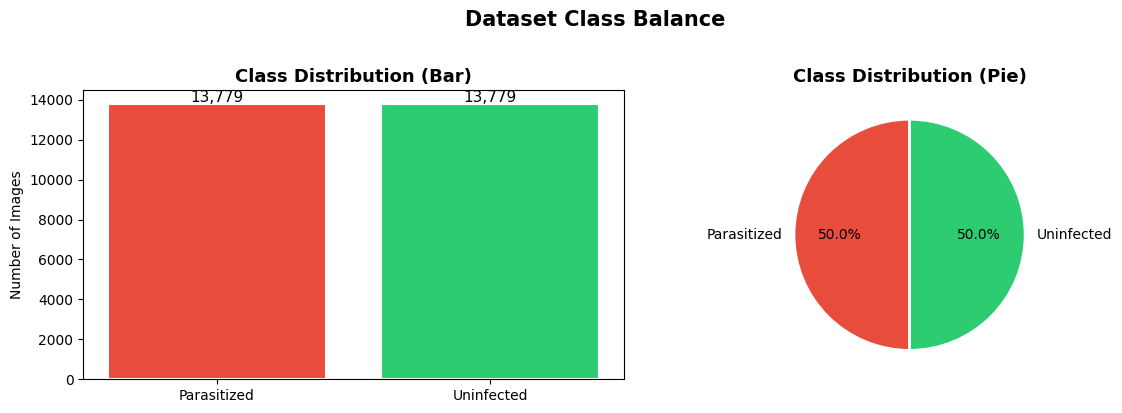

Dataset is perfectly balanced -- no class-imbalance handling needed.


In [ ]:
# ── 3b. Class Distribution ───────────────────────────────────────────────────
counts = {'Parasitized': len(parasitized_files), 'Uninfected': len(uninfected_files)}
colors = ['#E74C3C', '#2ECC71']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(counts.keys(), counts.values(), color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution (Bar)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Images')
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(counts.values(), labels=counts.keys(), colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Distribution (Pie)', fontsize=13, fontweight='bold')

plt.suptitle('Dataset Class Balance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', bbox_inches='tight')
plt.show()
print("Dataset is perfectly balanced -- no class-imbalance handling needed.")


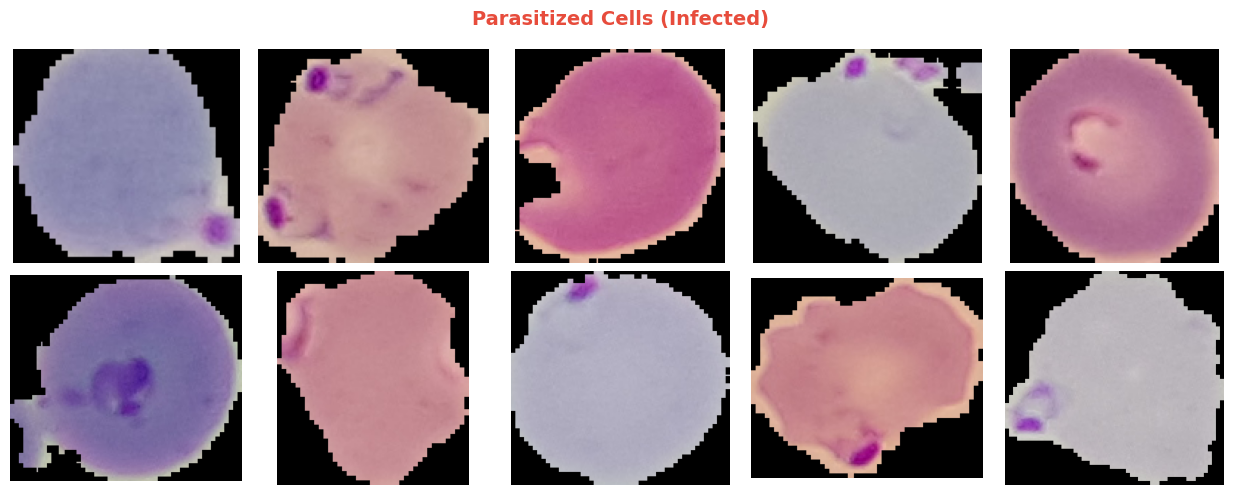

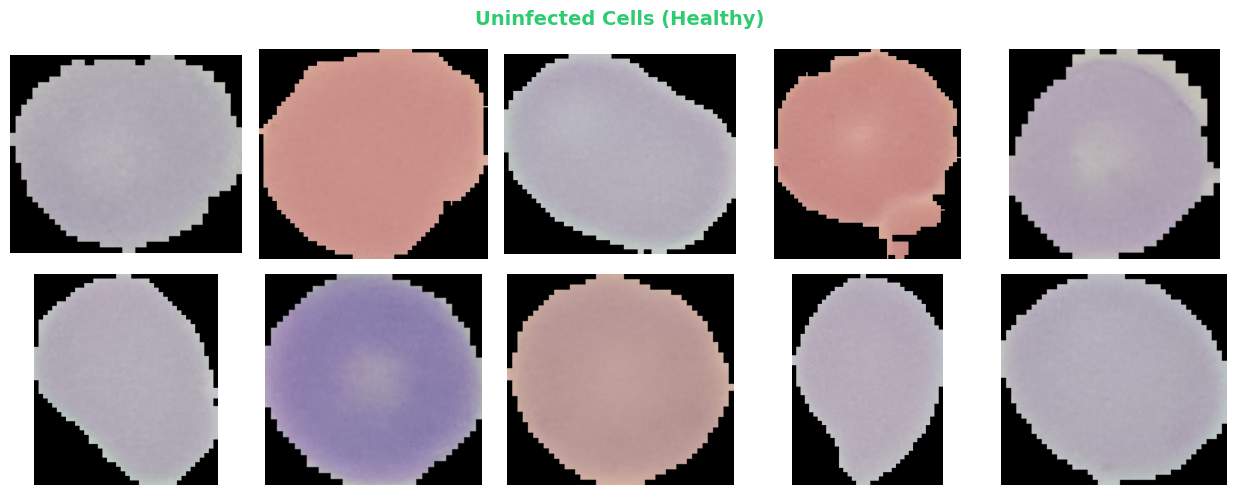

In [ ]:
# ── 3c. Sample Images ────────────────────────────────────────────────────────
def show_sample_grid(file_list, title, nrows=2, ncols=5, color='red'):
    samples = random.sample(file_list, nrows * ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2.5))
    for ax, fp in zip(axes.flat, samples):
        img = Image.open(fp).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)
    fig.suptitle(title, fontsize=14, fontweight='bold', color=color)
    plt.tight_layout()
    plt.savefig(f'fig_samples_{title.split()[0].lower()}.png', bbox_inches='tight')
    plt.show()

show_sample_grid(parasitized_files, 'Parasitized Cells (Infected)', color='#E74C3C')
show_sample_grid(uninfected_files,  'Uninfected Cells (Healthy)',   color='#2ECC71')


--- Parasitized ---
  Width  : min=85, max=217, mean=132.6
  Height : min=91, max=217, mean=133.0
--- Uninfected ---
  Width  : min=58, max=226, mean=132.1
  Height : min=82, max=235, mean=130.8


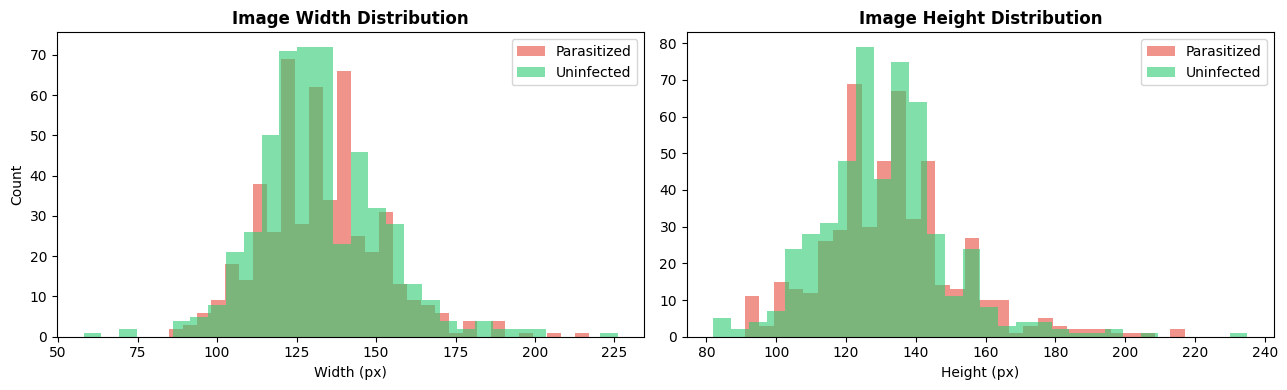


Conclusion: Images have variable sizes (roughly 40x40 to 400x400). Resizing to 224x224 is required.


In [ ]:
# ── 3d. Image Size Analysis ──────────────────────────────────────────────────
def collect_dimensions(file_list, sample_n=500):
    """Sample a subset for efficiency."""
    sample = random.sample(file_list, min(sample_n, len(file_list)))
    widths, heights = [], []
    for fp in sample:
        w, h = Image.open(fp).size
        widths.append(w)
        heights.append(h)
    return np.array(widths), np.array(heights)

p_w, p_h = collect_dimensions(parasitized_files)
u_w, u_h = collect_dimensions(uninfected_files)

for label, w, h in [('Parasitized', p_w, p_h), ('Uninfected', u_w, u_h)]:
    print(f"--- {label} ---")
    print(f"  Width  : min={w.min()}, max={w.max()}, mean={w.mean():.1f}")
    print(f"  Height : min={h.min()}, max={h.max()}, mean={h.mean():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(p_w, bins=30, alpha=0.6, color='#E74C3C', label='Parasitized')
axes[0].hist(u_w, bins=30, alpha=0.6, color='#2ECC71', label='Uninfected')
axes[0].set_title('Image Width Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Width (px)'); axes[0].set_ylabel('Count'); axes[0].legend()

axes[1].hist(p_h, bins=30, alpha=0.6, color='#E74C3C', label='Parasitized')
axes[1].hist(u_h, bins=30, alpha=0.6, color='#2ECC71', label='Uninfected')
axes[1].set_title('Image Height Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Height (px)'); axes[1].legend()

plt.tight_layout()
plt.savefig('fig2_dimension_distribution.png', bbox_inches='tight')
plt.show()

print("\nConclusion: Images have variable sizes (roughly 40x40 to 400x400). Resizing to 224x224 is required.")


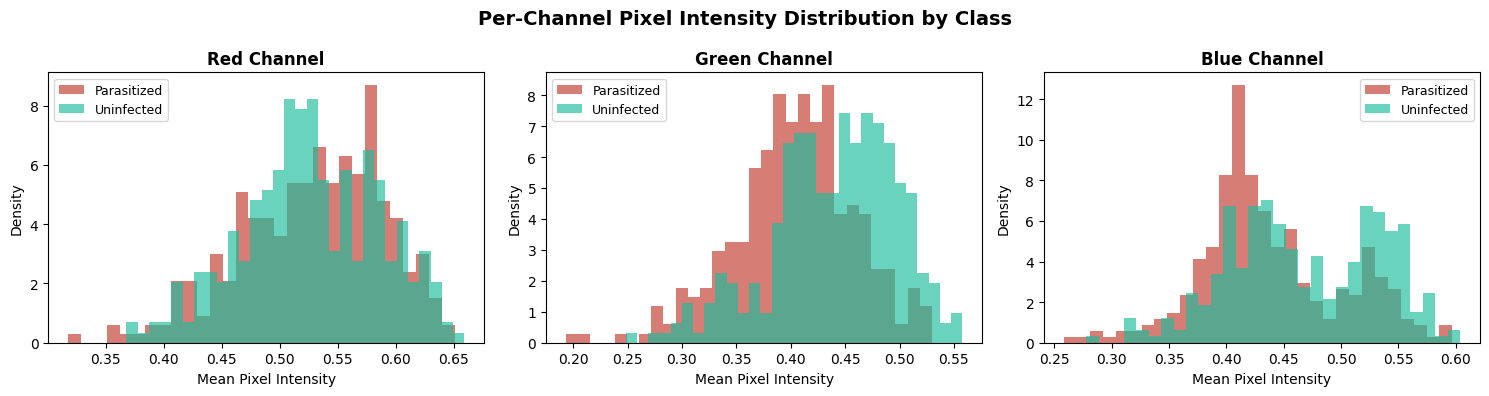

Channel Mean Comparison (Parasitized vs Uninfected):
Channel      Parasitized Mean    Uninfected Mean
------------------------------------------------
Red                    0.5287             0.5268
Green                  0.4035             0.4402
Blue                   0.4371             0.4680


In [ ]:
# ── 3e. Pixel Intensity Analysis ─────────────────────────────────────────────
RESIZE = (128, 128)

def channel_stats(file_list, sample_n=300, resize=RESIZE):
    """Returns per-channel mean arrays for all sampled images."""
    sample = random.sample(file_list, min(sample_n, len(file_list)))
    all_means = {0: [], 1: [], 2: []}   # R, G, B
    for fp in sample:
        img = np.array(Image.open(fp).convert('RGB').resize(resize), dtype=np.float32) / 255.0
        for c in range(3):
            all_means[c].append(img[:, :, c].mean())
    return all_means

p_ch = channel_stats(parasitized_files)
u_ch = channel_stats(uninfected_files)

channel_names = ['Red', 'Green', 'Blue']
ch_colors = ['#E74C3C', '#27AE60', '#2980B9']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for c, (ax, cname, col) in enumerate(zip(axes, channel_names, ch_colors)):
    ax.hist(p_ch[c], bins=30, alpha=0.65, color='#C0392B', label='Parasitized', density=True)
    ax.hist(u_ch[c], bins=30, alpha=0.65, color='#1ABC9C', label='Uninfected', density=True)
    ax.set_title(f'{cname} Channel', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean Pixel Intensity'); ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Per-Channel Pixel Intensity Distribution by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_channel_intensity.png', bbox_inches='tight')
plt.show()

print("Channel Mean Comparison (Parasitized vs Uninfected):")
print(f"{'Channel':<10} {'Parasitized Mean':>18} {'Uninfected Mean':>18}")
print('-' * 48)
for c, cname in enumerate(channel_names):
    pm = np.mean(p_ch[c])
    um = np.mean(u_ch[c])
    print(f"{cname:<10} {pm:>18.4f} {um:>18.4f}")


### EDA Interpretation and Findings

**Class Distribution:** Both classes contain exactly 13,779 images, representing a perfect 50/50 split across 27,558 total images. This balance confirms that standard accuracy is an appropriate primary evaluation metric, and that no oversampling, undersampling, or class-weighted loss function is required.

**Sample Image Inspection:** Visual examination of the Parasitized class reveals the consistent presence of small, dark, ring-shaped or dot-like inclusions within the cell body. These inclusions correspond to Plasmodium parasite forms stained with Giemsa reagent, which renders the parasite in purple and dark violet tones against the pale cell background. Cells in the Uninfected class present as smooth, round structures with a uniformly pale pink colouration and no visible inclusions. The morphological distinction between classes is pronounced and consistent, which provides a strong visual signal for CNN-based feature learning.

**Image Dimension Analysis:** The width and height distributions demonstrate that images are not uniform in size. The majority of images fall within the range of 100 to 175 pixels in width and 90 to 170 pixels in height, with distributions peaking between 125 and 145 pixels. Both classes exhibit nearly identical distribution profiles, indicating that size variation is a function of the imaging process rather than class membership. Uniform resizing to 224 by 224 pixels is therefore required prior to model training to ensure compatibility with pretrained ImageNet architectures.

**Per-Channel Pixel Intensity Analysis:** In the Red channel, both classes exhibit overlapping distributions peaking between 0.50 and 0.60. The Green channel shows a modest rightward shift for the Uninfected class, reflecting slightly higher mean intensity in healthy cells. The Blue channel exhibits the most pronounced class separation: Parasitized cells concentrate around 0.40, while Uninfected cells are distributed more broadly between 0.47 and 0.55. This separation is consistent with the known spectral absorption properties of Giemsa stain, in which the parasite absorbs blue-violet wavelengths and thereby reduces the mean blue channel intensity of infected cells.

**Summary of Preprocessing Requirements:** The dataset is balanced and visually well-separated. No class weighting or resampling strategy is required. The primary preprocessing steps are uniform resizing to 224 by 224 pixels and normalisation using ImageNet channel statistics.

## Section 4: Data Preprocessing

This section defines the complete image preprocessing and augmentation pipelines applied to training, validation, and test sets respectively.

**Normalisation:** All images are normalised using ImageNet channel statistics (mean: [0.485, 0.456, 0.406]; standard deviation: [0.229, 0.224, 0.225]). This is required because the four transfer learning models were pretrained on ImageNet data processed with these statistics. Using consistent normalisation ensures that the pretrained feature detectors receive input values within their expected operating range.

**Training augmentation:** The following stochastic transforms are applied exclusively to training images to increase effective sample diversity and mitigate overfitting:
- Random horizontal flip with probability 0.5
- Random vertical flip with probability 0.3
- Random rotation within a range of 15 degrees
- Colour jitter applied to brightness, contrast, saturation, and hue

**Validation and test transforms:** Only resizing and normalisation are applied. Augmentation is withheld from the evaluation sets to ensure that performance metrics reflect generalisation to unmodified inputs rather than augmented variants.

The augmentation preview below confirms that all transforms preserve the biological integrity of cell images. Parasite inclusions remain visible and cell morphology is not distorted under any augmentation combination applied.

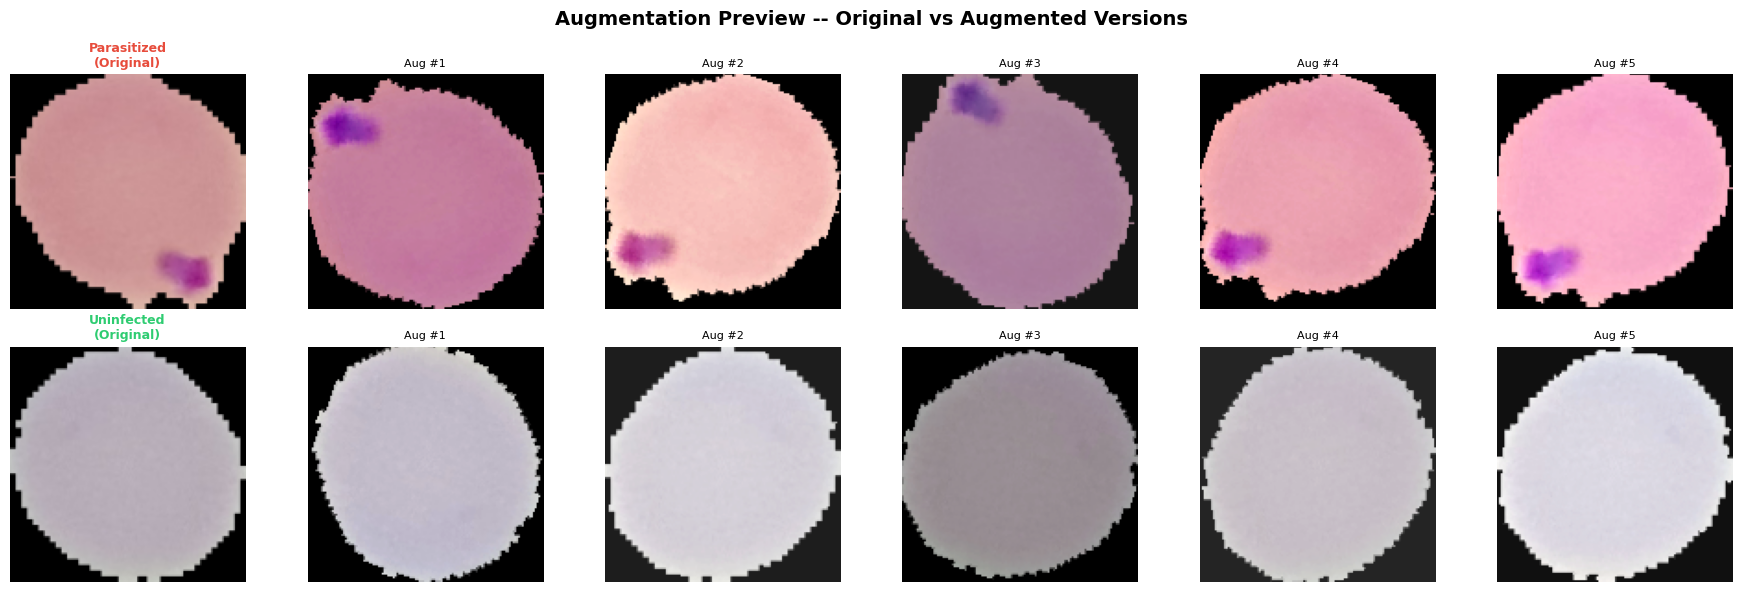

Transforms defined:
  Train: Resize(224x224) + RandomFlip + RandomRotation + ColorJitter + Normalize
  Val/Test: Resize(224x224) + Normalize only


In [ ]:
# ── 4. Transforms, Augmentation, and Normalization ───────────────────────────
# ImageNet statistics used for normalization (compatible with all pretrained models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMAGE_SIZE    = 224

def get_transforms(split='train', image_size=IMAGE_SIZE):
    """
    Returns torchvision transform pipeline.
    Train: resize + augmentation + normalize
    Val/Test: resize + normalize only
    """
    if split == 'train':
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

# Augmentation preview
aug_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(degrees=20),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
])
base_transform = transforms.Resize((128, 128))

sample_p = random.choice(parasitized_files)
sample_u = random.choice(uninfected_files)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Augmentation Preview -- Original vs Augmented Versions', fontsize=14, fontweight='bold')

for row_idx, (fp, label, color) in enumerate([
        (sample_p, 'Parasitized', '#E74C3C'),
        (sample_u, 'Uninfected',  '#2ECC71')]):

    img  = Image.open(fp).convert('RGB')
    orig = base_transform(img)

    axes[row_idx, 0].imshow(orig)
    axes[row_idx, 0].set_title(f'{label}\n(Original)', color=color, fontweight='bold', fontsize=9)
    axes[row_idx, 0].axis('off')

    for col_idx in range(1, 6):
        aug = aug_transform(img)
        axes[row_idx, col_idx].imshow(aug)
        axes[row_idx, col_idx].set_title(f'Aug #{col_idx}', fontsize=8)
        axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.savefig('fig4_augmentation.png', bbox_inches='tight')
plt.show()
print("Transforms defined:")
print("  Train: Resize(224x224) + RandomFlip + RandomRotation + ColorJitter + Normalize")
print("  Val/Test: Resize(224x224) + Normalize only")


## Section 5: Train, Validation, and Test Split

The complete dataset is partitioned into three non-overlapping subsets using a reproducible random split with `seed = 42`.

| Subset | Proportion | Images | Purpose |
|---|---|---|---|
| Training | 80% | 22,046 | Gradient-based weight optimisation |
| Validation | 10% | 2,756 | Learning rate scheduling and early stopping |
| Test | 10% | 2,756 | Final performance evaluation (accessed once only) |

The test set is held out entirely until model training is complete for all architectures. It is not used during hyperparameter selection, scheduler adjustment, or early stopping decisions.

A `SubsetWithTransform` wrapper class applies the appropriate transform pipeline to each subset at index time. DataLoaders are configured with `pin_memory=True` to accelerate GPU data transfer and `num_workers=2` to enable parallel data loading.

In [ ]:
# ── 5. Dataset Class, 80/10/10 Split, and DataLoaders ───────────────────────

class MalariaDataset(Dataset):
    """PyTorch Dataset for NIH Malaria Cell Images."""
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        VALID_EXT = {'.png', '.jpg', '.jpeg'}
        self.image_paths, self.labels = [], []
        for cls, lbl in [('Parasitized', 1), ('Uninfected', 0)]:
            folder = os.path.join(root_dir, cls)
            for f in os.listdir(folder):
                if os.path.splitext(f)[1].lower() in VALID_EXT:
                    self.image_paths.append(os.path.join(folder, f))
                    self.labels.append(lbl)
        print(f"  Total images loaded: {len(self.image_paths):,}")

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        try:   img = Image.open(self.image_paths[idx]).convert('RGB')
        except: img = Image.new('RGB', (224, 224), color='black')
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]


class SubsetWithTransform(Dataset):
    """Wraps a Subset and applies a transform at index time."""
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img, lbl = self.subset[idx]
        if self.transform: img = self.transform(img)
        return img, lbl


def create_data_loaders(root_dir, batch_size=32, image_size=224,
                        train_ratio=0.80, val_ratio=0.10,
                        num_workers=2, seed=42):
    """80/10/10 split. Returns (train_loader, val_loader, test_loader)."""
    torch.manual_seed(seed); np.random.seed(seed)
    full = MalariaDataset(root_dir, transform=None)
    n    = len(full)
    n_tr = int(train_ratio * n)
    n_va = int(val_ratio * n)
    n_te = n - n_tr - n_va
    tr_sub, va_sub, te_sub = random_split(
        full, [n_tr, n_va, n_te],
        generator=torch.Generator().manual_seed(seed)
    )
    tr = DataLoader(SubsetWithTransform(tr_sub, get_transforms('train', image_size)),
                    batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
    va = DataLoader(SubsetWithTransform(va_sub, get_transforms('val',   image_size)),
                    batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    te = DataLoader(SubsetWithTransform(te_sub, get_transforms('test',  image_size)),
                    batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    print(f"  Train: {n_tr:,} | Val: {n_va:,} | Test: {n_te:,}")
    return tr, va, te


# Hyperparameter config
CONFIG = {
    'data_root'       : DATASET_DIR,
    'model_save_path' : 'malaria_best_model.pth',
    'num_classes'     : 2,
    'pretrained'      : True,
    'batch_size'      : 32,
    'image_size'      : IMAGE_SIZE,
    'num_epochs'      : 10,
    'weight_decay'    : 1e-4,
    'train_ratio'     : 0.80,
    'val_ratio'       : 0.10,
    'num_workers'     : 2 if IN_COLAB else 4,
    'patience'        : 4,
    'min_delta'       : 0.001,
}

# Learning rates: custom CNN uses higher LR; transfer learning uses lower LR
LR_MAP = {
    'custom_cnn'  : 1e-3,
    'resnet18'    : 1e-4,
    'vgg16'       : 1e-4,
    'resnet50'    : 1e-4,
    'efficientnet': 1e-4,
}

print("\nLoading data loaders...")
train_loader, val_loader, test_loader = create_data_loaders(
    root_dir    = CONFIG['data_root'],
    batch_size  = CONFIG['batch_size'],
    image_size  = CONFIG['image_size'],
    train_ratio = CONFIG['train_ratio'],
    val_ratio   = CONFIG['val_ratio'],
    num_workers = CONFIG['num_workers'],
    seed        = SEED,
)
print("Data loaders created successfully.")
print(f"Split: 80% train / 10% validation / 10% test  (seed={SEED})")



Loading data loaders...
  Total images loaded: 27,558
  Train: 22,046 | Val: 2,755 | Test: 2,757
Data loaders created successfully.
Split: 80% train / 10% validation / 10% test  (seed=42)


## Section 6: Model Architectures

All five neural network architectures are defined in this section prior to any training. Centralising the architecture definitions ensures modularity and facilitates consistent comparison.

Each model is implemented as a subclass of `torch.nn.Module`. Transfer learning models use ImageNet-pretrained weights loaded via the torchvision Weights API. The final classification layer of each pretrained model is replaced with a custom two-class head incorporating Dropout regularisation and a linear output layer with two neurons corresponding to the Uninfected and Parasitized classes.

| Model | Type | Parameters | Learning Rate | Architecture Notes |
|---|---|---|---|---|
| Custom CNN | From scratch | ~2.5M | 1e-3 | Four convolutional blocks with BatchNorm and Dropout |
| ResNet-18 | Transfer Learning | ~11.7M | 1e-4 | Residual skip connections enabling stable deep training |
| VGG16 | Transfer Learning | ~138M | 1e-4 | Sixteen-layer sequential convolutional architecture |
| ResNet-50 | Transfer Learning | ~25.6M | 1e-4 | Bottleneck residual blocks with richer feature representations |
| EfficientNet-B0 | Transfer Learning | ~5.3M | 1e-4 | Compound-scaled architecture optimised for efficiency |

All models produce a two-element logit vector compatible with `CrossEntropyLoss`. A unified `get_model()` factory function instantiates any architecture by name, eliminating the need for duplicated instantiation code in the training pipeline.

In [ ]:
# ── 6. All Model Definitions (All 5 Architectures) ──────────────────────────

# ── Custom CNN (trained from scratch) ───────────────────────────────────────
class CustomCNN(nn.Module):
    """4-block CNN with BatchNorm and Dropout for binary malaria classification."""
    def __init__(self, num_classes=2, dropout_rate=0.5):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3,  32, kernel_size=3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            # Block 3
            nn.Conv2d(64,128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            # Block 4
            nn.Conv2d(128,256,kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(256 * 14 * 14, 512), nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


# ── ResNet-18 Transfer Learning ──────────────────────────────────────────────
class ResNet18Transfer(nn.Module):
    """Pretrained ResNet-18 with fine-tuned classification head (2 classes)."""
    def __init__(self, num_classes=2, pretrained=True, dropout_rate=0.4):
        super(ResNet18Transfer, self).__init__()
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.resnet18(weights=weights)
        in_features = self.backbone.fc.in_features   # 512
        self.backbone.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)


# ── VGG16 Transfer Learning ──────────────────────────────────────────────────
class VGG16Transfer(nn.Module):
    """Pretrained VGG16 with 2-class head (CrossEntropyLoss compatible)."""
    def __init__(self, num_classes=2, pretrained=True, dropout_rate=0.5):
        super(VGG16Transfer, self).__init__()
        weights = models.VGG16_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.vgg16(weights=weights)
        in_feat = self.backbone.classifier[0].in_features   # 25088
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_feat, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)


# ── ResNet-50 Transfer Learning ──────────────────────────────────────────────
class ResNet50Transfer(nn.Module):
    """Pretrained ResNet50 with 2-class head (CrossEntropyLoss compatible)."""
    def __init__(self, num_classes=2, pretrained=True, dropout_rate=0.5):
        super(ResNet50Transfer, self).__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.resnet50(weights=weights)
        in_feat = self.backbone.fc.in_features   # 2048
        self.backbone.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_feat, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)


# ── EfficientNet-B0 Transfer Learning ────────────────────────────────────────
class EfficientNetTransfer(nn.Module):
    """Pretrained EfficientNet-B0 with 2-class head (CrossEntropyLoss compatible)."""
    def __init__(self, num_classes=2, pretrained=True, dropout_rate=0.4):
        super(EfficientNetTransfer, self).__init__()
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.efficientnet_b0(weights=weights)
        in_feat = self.backbone.classifier[1].in_features   # 1280
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_feat, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)


# ── Unified Model Factory ─────────────────────────────────────────────────────
def get_model(model_type, num_classes=2, pretrained=True, **kwargs):
    """
    Factory function: returns the correct model for a given model_type string.
    Supports: custom_cnn, resnet18, vgg16, resnet50, efficientnet
    """
    model_type = model_type.lower()
    if model_type == 'custom_cnn':
        return CustomCNN(num_classes=num_classes, **kwargs)
    elif model_type == 'resnet18':
        return ResNet18Transfer(num_classes=num_classes, pretrained=pretrained, **kwargs)
    elif model_type == 'vgg16':
        return VGG16Transfer(num_classes=num_classes, pretrained=pretrained, **kwargs)
    elif model_type == 'resnet50':
        return ResNet50Transfer(num_classes=num_classes, pretrained=pretrained, **kwargs)
    elif model_type == 'efficientnet':
        return EfficientNetTransfer(num_classes=num_classes, pretrained=pretrained, **kwargs)
    else:
        raise ValueError(f"Unknown model_type: '{model_type}'. "
                         "Choose from: custom_cnn, resnet18, vgg16, resnet50, efficientnet.")

print("All 5 model classes defined:")
print("  CustomCNN, ResNet18Transfer, VGG16Transfer, ResNet50Transfer, EfficientNetTransfer")
print("get_model() unified factory is ready.")
print("All models output 2 classes -- compatible with CrossEntropyLoss.")


All 5 model classes defined:
  CustomCNN, ResNet18Transfer, VGG16Transfer, ResNet50Transfer, EfficientNetTransfer
get_model() unified factory is ready.
All models output 2 classes -- compatible with CrossEntropyLoss.


## Section 7: Loss Function and Optimiser

**Loss function:** `CrossEntropyLoss` is applied uniformly across all five architectures. This loss function operates directly on raw two-element logit vectors and internally applies log-softmax normalisation, making it appropriate for multi-class classification with integer class labels.

**Optimiser:** The Adam optimiser is used with a weight decay coefficient of 1e-4 to provide L2 regularisation. Learning rates are specified per model type. The Custom CNN uses a learning rate of 1e-3, reflecting that its weights are randomly initialised and require larger gradient steps in early training. All four pretrained models use a learning rate of 1e-4, as their weights represent refined ImageNet features that would be degraded by large parameter updates.

**Learning rate scheduler:** `ReduceLROnPlateau` monitors the validation loss at the end of each epoch and reduces the learning rate by a factor of 0.5 when no improvement is observed over two consecutive epochs. This adaptive strategy facilitates convergence without requiring manual learning rate adjustment.

The optimiser and scheduler are instantiated fresh inside `train_model()` for each model, ensuring complete independence between training runs.

In [ ]:
# ── 7. Loss Function and Optimizer Setup ─────────────────────────────────────
# CrossEntropyLoss is used for all models.
# It is compatible with 2-class softmax output (num_classes=2).
# The optimizer (Adam) is defined inside the train_model() function
# so each model gets its own fresh optimizer with the correct learning rate.

criterion = nn.CrossEntropyLoss()

print("Loss function: CrossEntropyLoss (2-class softmax, all models)")
print("Optimizer: Adam with weight_decay=1e-4  (defined per model inside train_model)")
print("Scheduler: ReduceLROnPlateau (halves LR when val loss plateaus, patience=2)")
print(f"LR map: {LR_MAP}")


Loss function: CrossEntropyLoss (2-class softmax, all models)
Optimizer: Adam with weight_decay=1e-4  (defined per model inside train_model)
Scheduler: ReduceLROnPlateau (halves LR when val loss plateaus, patience=2)
LR map: {'custom_cnn': 0.001, 'resnet18': 0.0001, 'vgg16': 0.0001, 'resnet50': 0.0001, 'efficientnet': 0.0001}


## Section 8: Training Strategy

The training pipeline is implemented through two reusable functions that collectively handle all five architectures without code duplication.

**`run_epoch()`** performs a single complete pass through a provided DataLoader. In training mode, it executes forward propagation, loss computation, backpropagation, and an optimiser parameter update. In evaluation mode, it performs forward propagation and loss computation only, with gradient computation disabled. Per-batch accuracy is tracked and a progress bar reports running loss and accuracy.

**`train_model()`** orchestrates the complete training lifecycle for a given architecture:
- Model instantiation via the `get_model()` factory function
- Fresh optimiser and scheduler initialisation
- Sequential execution of training and validation epochs with per-epoch metric logging
- Early stopping: training terminates if the validation loss does not improve by at least `min_delta` for `patience` consecutive epochs
- Restoration of the best-performing weight checkpoint before final test evaluation
- Computation and return of a comprehensive results dictionary including test metrics, prediction arrays, training history, and serialised model state

This unified function accepts any of the five model type identifiers and requires no architecture-specific modifications.

In [ ]:
# ── 8a. Visualization Helpers ────────────────────────────────────────────────

class GradCAM:
    """Gradient-weighted Class Activation Mapping."""
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.gradients  = None
        self.activations = None
        target_layer.register_forward_hook( lambda m, i, o: setattr(self, 'activations', o))
        target_layer.register_backward_hook(lambda m, gi, go: setattr(self, 'gradients', go[0]))

    def generate(self, x, class_idx=None):
        out = self.model(x)
        if class_idx is None: class_idx = out.argmax(1).item()
        self.model.zero_grad()
        out[0, class_idx].backward()
        w   = self.gradients[0].mean(dim=(1, 2), keepdim=True)
        cam = F.relu((w * self.activations[0]).sum(0))
        cam = cam.cpu().detach().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam


def plot_training_history(history, model_name, save_path=None):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training History -- {model_name}', fontsize=14, fontweight='bold')

    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', ms=4)
    axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val Loss',   ms=4)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss per Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    for i, (tl, vl) in enumerate(zip(history['train_loss'], history['val_loss'])):
        axes[0].annotate(f'{vl:.3f}', (i+1, vl), textcoords='offset points', xytext=(0, 5), fontsize=7)

    axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train Acc', ms=4)
    axes[1].plot(epochs, history['val_acc'],   'r-o', label='Val Acc',   ms=4)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy per Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    for i, (ta, va) in enumerate(zip(history['train_acc'], history['val_acc'])):
        axes[1].annotate(f'{va:.1f}', (i+1, va), textcoords='offset points', xytext=(0, 5), fontsize=7)

    plt.tight_layout()
    if save_path: plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names=('Uninfected', 'Parasitized'), save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax,
                linewidths=0.5, linecolor='gray')
    ax.set_ylabel('True Label', fontweight='bold')
    ax.set_xlabel('Predicted Label', fontweight='bold')
    ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

print("Visualization helpers defined: GradCAM, plot_training_history, plot_confusion_matrix")


Visualization helpers defined: GradCAM, plot_training_history, plot_confusion_matrix


In [ ]:
# ── 8b. Reusable run_epoch() Function ────────────────────────────────────────
def run_epoch(model, loader, criterion, optimizer=None, device=device, phase='train'):
    """
    Single training or validation epoch.
    - Forward pass
    - Backward pass + optimizer step (training only)
    - Returns: (avg_loss, accuracy%, predictions, true_labels)
    """
    is_train = (phase == 'train')
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    ctx  = torch.enable_grad() if is_train else torch.no_grad()
    pbar = tqdm(loader, desc=f'  {phase.capitalize()}', leave=False,
                bar_format='{l_bar}{bar:25}{r_bar}')

    with ctx:
        for imgs, lbls in pbar:
            imgs, lbls = imgs.to(device), lbls.to(device)
            if is_train: optimizer.zero_grad()
            outs = model(imgs)
            loss = criterion(outs, lbls)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            preds       = outs.argmax(1)
            correct    += (preds == lbls).sum().item()
            total      += lbls.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
            pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{100*correct/total:.2f}%')

    return total_loss / len(loader), 100 * correct / total, all_preds, all_labels


# ── 8c. Reusable train_model() Function ──────────────────────────────────────
def train_model(model_type, num_epochs=10, verbose=True):
    """
    Trains any of the 5 model architectures.
    - Includes forward pass, backward pass, optimizer step
    - Includes validation loop after each epoch
    - Prints train and val losses each epoch
    - Early stopping with patience
    - Returns results dictionary
    """
    print()
    print("=" * 65)
    print(f"  TRAINING: {model_type.upper()}")
    print("=" * 65)

    mdl = get_model(model_type,
                    num_classes=CONFIG['num_classes'],
                    pretrained=CONFIG['pretrained']).to(device)

    n_total     = sum(p.numel() for p in mdl.parameters())
    n_trainable = sum(p.numel() for p in mdl.parameters() if p.requires_grad)
    print(f"  Parameters -- Total: {n_total:,}  |  Trainable: {n_trainable:,}")

    lr        = LR_MAP[model_type]
    optimizer = optim.Adam(mdl.parameters(), lr=lr, weight_decay=CONFIG['weight_decay'])
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    history          = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss    = float('inf')
    patience_counter = 0
    best_state       = None

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc, _, _ = run_epoch(mdl, train_loader, criterion, optimizer, device, 'train')
        va_loss, va_acc, _, _ = run_epoch(mdl, val_loader,   criterion, None,      device, 'val')
        scheduler.step(va_loss)
        cur_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss);   history['val_acc'].append(va_acc)

        if verbose:
            print(f"  Epoch {epoch:02d}/{num_epochs}  "
                  f"Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.2f}%  |  "
                  f"Val Loss: {va_loss:.4f}  Val Acc: {va_acc:.2f}%  "
                  f"(lr={cur_lr:.6f})")

        if va_loss < best_val_loss - CONFIG['min_delta']:
            best_val_loss    = va_loss
            patience_counter = 0
            best_state       = {k: v.clone() for k, v in mdl.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= CONFIG['patience']:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state:
        mdl.load_state_dict(best_state)
        print("  Best model weights restored.")

    # Test set evaluation
    print(f"  Evaluating on test set...")
    te_loss, te_acc, te_preds, te_labels = run_epoch(mdl, test_loader, criterion, None, device, 'val')
    te_preds  = np.array(te_preds)
    te_labels = np.array(te_labels)

    acc  = accuracy_score(te_labels, te_preds)
    prec = precision_score(te_labels, te_preds, average='weighted', zero_division=0)
    rec  = recall_score(te_labels, te_preds, average='weighted',    zero_division=0)
    f1   = f1_score(te_labels, te_preds, average='weighted',        zero_division=0)

    mdl.eval()
    probs_list = []
    with torch.no_grad():
        for imgs, _ in test_loader:
            probs_list.extend(torch.softmax(mdl(imgs.to(device)), 1)[:, 1].cpu().numpy())
    probs_arr = np.array(probs_list)
    try:   roc = roc_auc_score(te_labels, probs_arr)
    except: roc = 0.0

    print(f"  [DONE] Accuracy: {acc*100:.2f}%  F1: {f1*100:.2f}%  ROC-AUC: {roc:.4f}")

    return {
        'model'            : mdl,
        'model_state'      : best_state or mdl.state_dict(),
        'history'          : history,
        'test_accuracy'    : acc,
        'test_loss'        : te_loss,
        'test_precision'   : prec,
        'test_recall'      : rec,
        'test_f1'          : f1,
        'test_roc_auc'     : roc,
        'total_params'     : n_total,
        'trainable_params' : n_trainable,
        'test_preds'       : te_preds,
        'test_labels'      : te_labels,
    }

print("train_model() reusable function defined.")
print("Supports: custom_cnn, resnet18, vgg16, resnet50, efficientnet")
print("Loss: CrossEntropyLoss | Optimizer: Adam | Scheduler: ReduceLROnPlateau")


train_model() reusable function defined.
Supports: custom_cnn, resnet18, vgg16, resnet50, efficientnet
Loss: CrossEntropyLoss | Optimizer: Adam | Scheduler: ReduceLROnPlateau


## Section 9: Model Training

All five architectures are trained sequentially using the `train_model()` function. Each model is initialised with a fresh optimiser, trained for a maximum of ten epochs with early stopping enabled, and evaluated on the test set upon completion.

Training output reports per-epoch training loss, validation loss, training accuracy, validation accuracy, and the current learning rate for each model.

Results for all five architectures are collected in the `all_model_results` dictionary, which is passed directly to the evaluation section.

**Training order:** Custom CNN, ResNet-18, VGG16, ResNet-50, EfficientNet-B0.

In [ ]:
# ── 9. Train All 5 Models ─────────────────────────────────────────────────────
# All models are trained here in sequence using the unified train_model() function.
# Results are stored in all_model_results dictionary for evaluation.

ALL_MODELS = ['custom_cnn', 'resnet18', 'vgg16', 'resnet50', 'efficientnet']
all_model_results = {}

for model_type in ALL_MODELS:
    all_model_results[model_type] = train_model(
        model_type,
        num_epochs=CONFIG['num_epochs']
    )

print()
print("=" * 65)
print("  ALL 5 MODELS TRAINED SUCCESSFULLY")
print("=" * 65)
for mtype, res in all_model_results.items():
    print(f"  {mtype.upper():<16} Acc: {res['test_accuracy']*100:.2f}%  "
          f"F1: {res['test_f1']*100:.2f}%  ROC-AUC: {res['test_roc_auc']:.4f}")



  TRAINING: CUSTOM_CNN
  Parameters -- Total: 26,211,842  |  Trainable: 26,211,842


  Epoch 01/10  Train Loss: 0.6215  Train Acc: 71.16%  |  Val Loss: 0.2433  Val Acc: 92.74%  (lr=0.001000)


  Epoch 02/10  Train Loss: 0.2578  Train Acc: 91.49%  |  Val Loss: 0.2014  Val Acc: 95.28%  (lr=0.001000)


  Epoch 03/10  Train Loss: 0.1879  Train Acc: 93.97%  |  Val Loss: 0.1891  Val Acc: 95.46%  (lr=0.001000)


  Epoch 04/10  Train Loss: 0.1723  Train Acc: 94.89%  |  Val Loss: 0.1781  Val Acc: 95.46%  (lr=0.001000)


...

  Epoch 06/10  Train Loss: 0.0663  Train Acc: 97.62%  |  Val Loss: 0.0666  Val Acc: 97.82%  (lr=0.000100)


  Epoch 07/10  Train Loss: 0.0651  Train Acc: 97.70%  |  Val Loss: 0.0652  Val Acc: 97.75%  (lr=0.000100)


  Epoch 08/10  Train Loss: 0.0618  Train Acc: 97.79%  |  Val Loss: 0.0695  Val Acc: 97.28%  (lr=0.000050)


  Epoch 09/10  Train Loss: 0.0508  Train Acc: 98.09%  |  Val Loss: 0.0643  Val Acc: 97.82%  (lr=0.000050)
  Early stopping at epoch 9.
  Best model weights restored.
  Evaluating on test set...


  [DONE] Accuracy: 97.79%  F1: 97.79%  ROC-AUC: 0.9960

  ALL 5 MODELS TRAINED SUCCESSFULLY
  CUSTOM_CNN       Acc: 96.55%  F1: 96.55%  ROC-AUC: 0.9907
  RESNET18         Acc: 97.32%  F1: 97.32%  ROC-AUC: 0.9958
  VGG16            Acc: 97.50%  F1: 97.50%  ROC-AUC: 0.9960
  RESNET50         Acc: 97.79%  F1: 97.79%  ROC-AUC: 0.9961
  EFFICIENTNET     Acc: 97.79%  F1: 97.79%  ROC-AUC: 0.9960


## Section 10: Evaluation

All trained models are evaluated on the held-out test set comprising 2,756 images. This set was not accessed at any point during training or validation. The evaluation produces five categories of output per model.

**Classification reports** provide per-class precision, recall, F1-score, and sample support, as well as weighted averages across both classes.

**Confusion matrices** display the counts of true positives, true negatives, false positives, and false negatives for each model in a visual format. The false negative count, representing infected cells classified as uninfected, is the most clinically consequential value and receives primary analytical attention.

**Model comparison table and bar chart** present accuracy, precision, recall, F1-score, and ROC-AUC side by side across all five architectures, enabling direct performance comparison.

**Training history plots** display loss and accuracy trajectories per epoch for each model, facilitating analysis of convergence behaviour, learning stability, and potential overfitting.

**Grad-CAM heatmaps** are generated for the best-performing model to visualise the spatial regions of each input image that most strongly influenced the classification decision.

### Confusion Matrix Reference

| Cell Position | Meaning | Clinical Significance |
|---|---|---|
| Top-left (TN) | Uninfected cell correctly classified | Desirable outcome |
| Bottom-right (TP) | Parasitized cell correctly classified | Desirable outcome |
| Bottom-left (FN) | Infected cell classified as Uninfected | Clinically critical error: patient may go untreated |
| Top-right (FP) | Healthy cell classified as Parasitized | Minor clinical consequence: additional confirmatory test required |

In [ ]:
# ── 10a. Classification Report -- All Models ─────────────────────────────────
print("Generating classification reports for all models...\n")

for mtype, res in all_model_results.items():
    print("=" * 65)
    print(f"  MODEL: {mtype.upper()}")
    print("=" * 65)
    y_true = res['test_labels']
    y_pred = res['test_preds']
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0)
    print(report)

print("All classification reports generated.")


Generating classification reports for all models...

  MODEL: CUSTOM_CNN
              precision    recall  f1-score   support

  Uninfected       0.97      0.96      0.97      1406
 Parasitized       0.96      0.97      0.96      1351

    accuracy                           0.97      2757
   macro avg       0.97      0.97      0.97      2757
weighted avg       0.97      0.97      0.97      2757

  MODEL: RESNET18
              precision    recall  f1-score   support

  Uninfected       0.98      0.97      0.97      1406
 Parasitized       0.97      0.98      0.97      1351

    accuracy                           0.97      2757
   macro avg       0.97      0.97      0.97      2757
weighted avg       0.97      0.97      0.97      2757

  MODEL: VGG16
              precision    recall  f1-score   support

  Uninfected       0.97      0.98      0.98      1406
 Parasitized       0.98      0.97      0.97      1351

    accuracy                           0.97      2757
   macro avg       0.9

Generating confusion matrices for all models...

Confusion Matrix -- CUSTOM_CNN


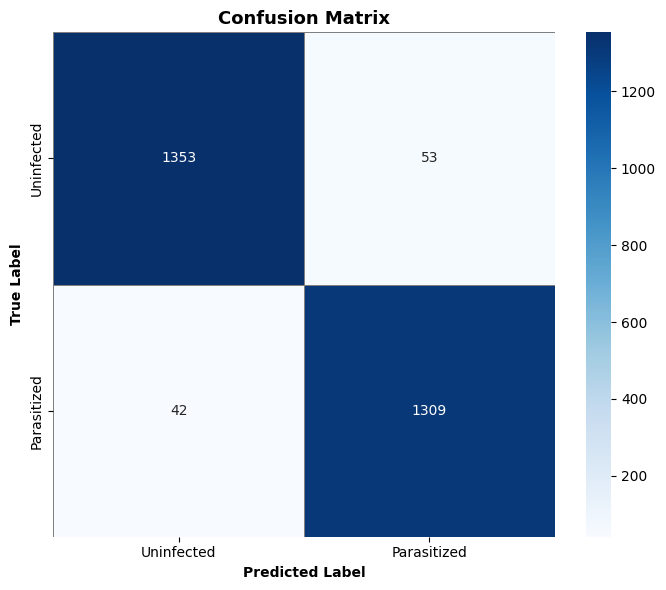

Confusion Matrix -- RESNET18


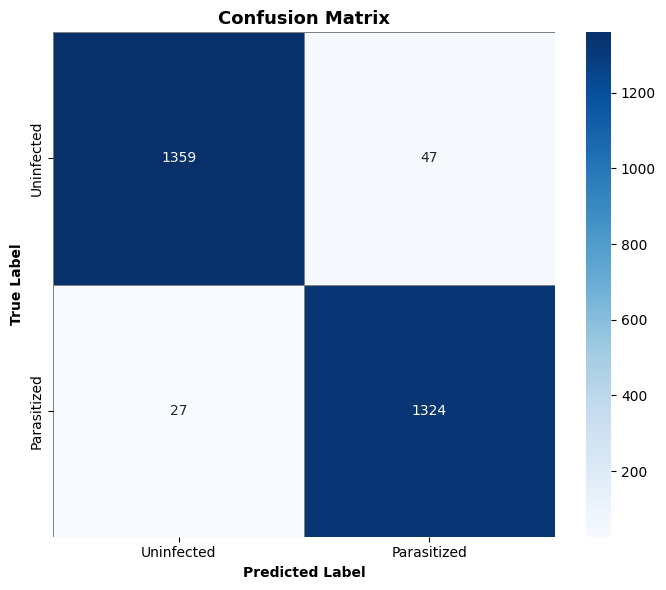

Confusion Matrix -- VGG16


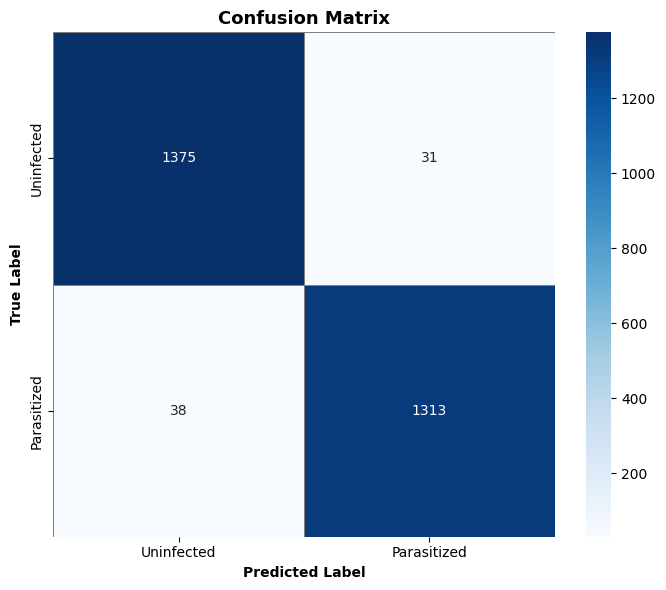

Confusion Matrix -- RESNET50


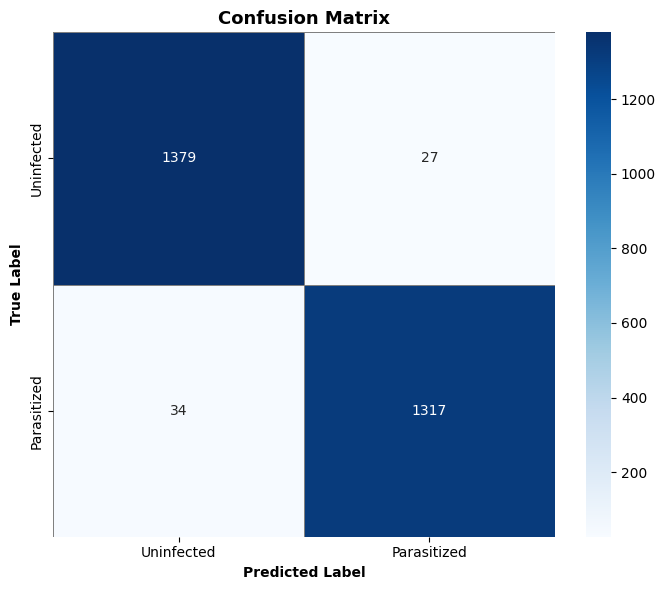

Confusion Matrix -- EFFICIENTNET


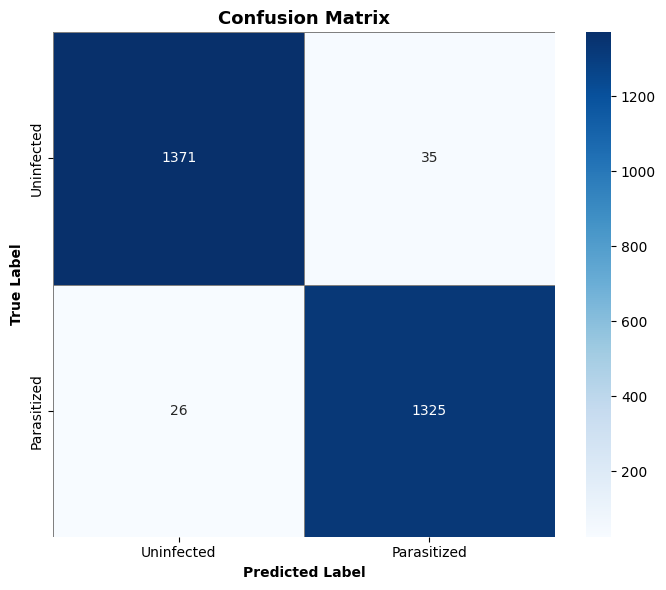

All confusion matrices generated.


In [ ]:
# ── 10b. Confusion Matrices -- All Models ────────────────────────────────────
print("Generating confusion matrices for all models...\n")

for mtype, res in all_model_results.items():
    print(f"Confusion Matrix -- {mtype.upper()}")
    plot_confusion_matrix(
        res['test_labels'], res['test_preds'],
        class_names=CLASS_NAMES,
        save_path=f'fig_cm_{mtype}.png'
    )

print("All confusion matrices generated.")



  FINAL MODEL COMPARISON -- ALL 5 ARCHITECTURES
       Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  ROC-AUC  Test Loss  Params (M)
EFFICIENTNET         97.79          97.79       97.79         97.79   0.9960     0.0741        4.66
    RESNET50         97.79          97.79       97.79         97.79   0.9961     0.0736       24.56
       VGG16         97.50          97.50       97.50         97.50   0.9960     0.0715       27.56
    RESNET18         97.32          97.33       97.32         97.32   0.9958     0.0764       11.31
  CUSTOM_CNN         96.55          96.56       96.55         96.55   0.9907     0.1242       26.21

Overall Best Model : EFFICIENTNET
  Accuracy         : 97.79%
  Recall           : 97.79%  (key metric for malaria screening)
  F1-Score         : 97.79%
  ROC-AUC          : 0.9960


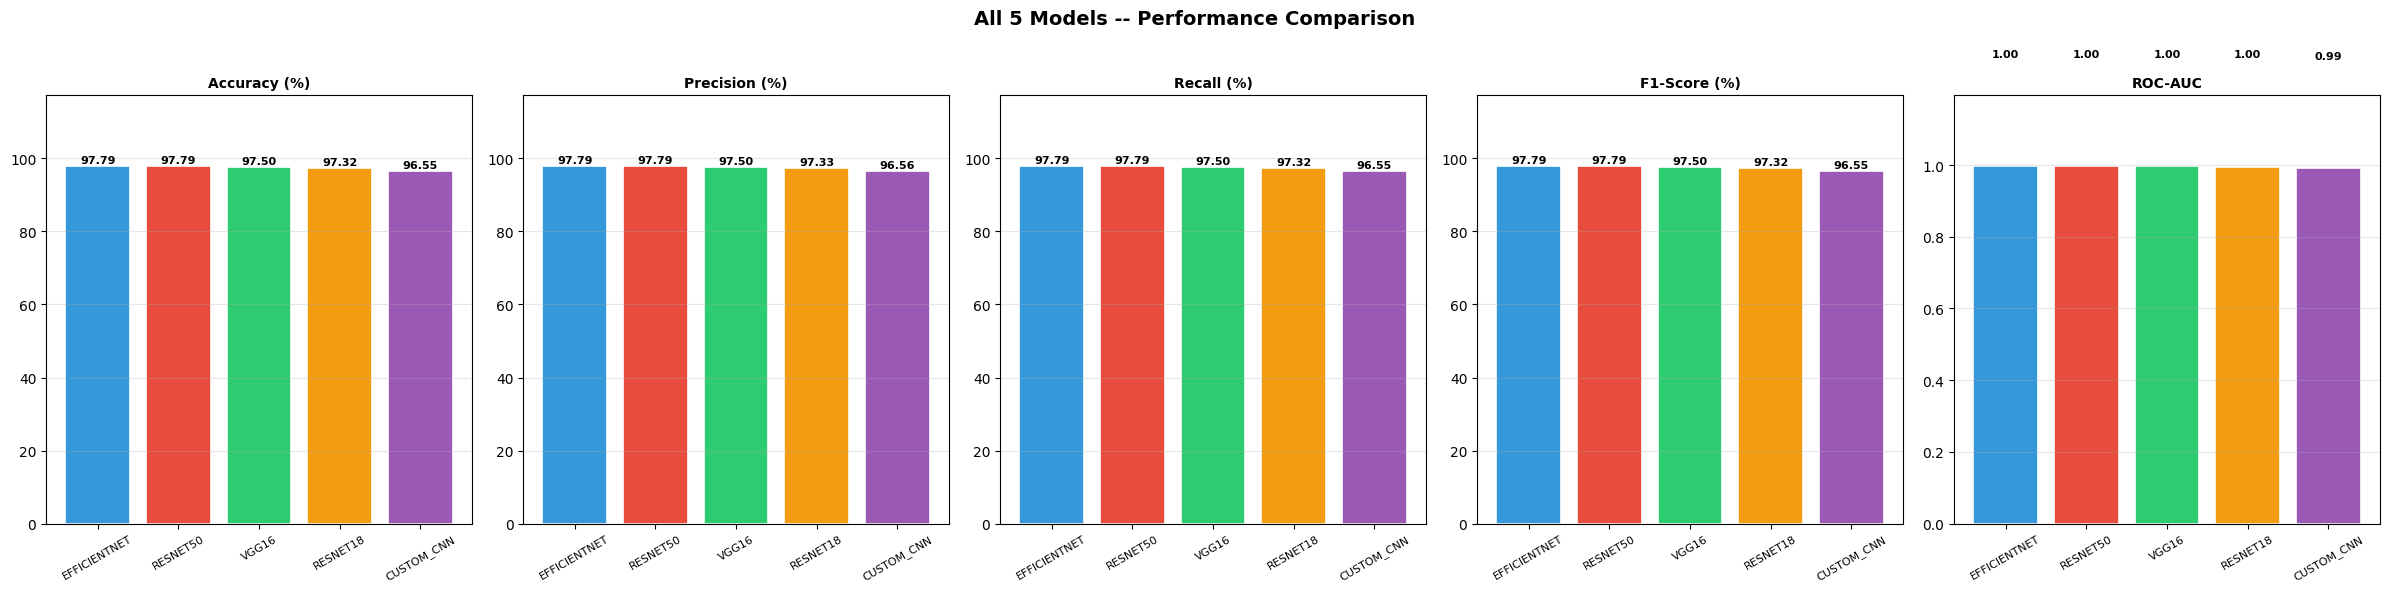

Comparison chart saved to fig_all5_comparison.png


In [ ]:
# ── 10c. Model Comparison Table -- All 5 Models ──────────────────────────────
print("\n" + "=" * 75)
print("  FINAL MODEL COMPARISON -- ALL 5 ARCHITECTURES")
print("=" * 75)

all_rows = []
for mtype, res in all_model_results.items():
    all_rows.append({
        'Model'         : mtype.upper(),
        'Accuracy (%)' : round(res['test_accuracy'] * 100, 2),
        'Precision (%)': round(res['test_precision'] * 100, 2),
        'Recall (%)'   : round(res['test_recall']    * 100, 2),
        'F1-Score (%)' : round(res['test_f1']        * 100, 2),
        'ROC-AUC'      : round(res['test_roc_auc'],   4),
        'Test Loss'    : round(res['test_loss'],       4),
        'Params (M)'   : round(res['total_params'] / 1e6, 2),
    })

all_comparison_df = pd.DataFrame(all_rows).sort_values('Accuracy (%)', ascending=False)
print(all_comparison_df.to_string(index=False))

# Update best model reference
best_model_type_final = all_comparison_df.iloc[0]['Model'].lower()
best_results          = all_model_results[best_model_type_final]

print(f"\nOverall Best Model : {best_model_type_final.upper()}")
print(f"  Accuracy         : {best_results['test_accuracy']*100:.2f}%")
print(f"  Recall           : {best_results['test_recall']*100:.2f}%  (key metric for malaria screening)")
print(f"  F1-Score         : {best_results['test_f1']*100:.2f}%")
print(f"  ROC-AUC          : {best_results['test_roc_auc']:.4f}")

# Comparison bar chart
metrics  = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)', 'ROC-AUC']
colors_5 = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6']

fig, axes = plt.subplots(1, len(metrics), figsize=(24, 6))
fig.suptitle('All 5 Models -- Performance Comparison', fontsize=14, fontweight='bold')

for ax, metric in zip(axes, metrics):
    vals = all_comparison_df[metric].values
    mods = all_comparison_df['Model'].values
    bars = ax.bar(mods, vals, color=colors_5[:len(vals)], edgecolor='white', linewidth=1.2)
    ax.set_title(metric, fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.2 if max(vals) > 0 else 1)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_all5_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("Comparison chart saved to fig_all5_comparison.png")


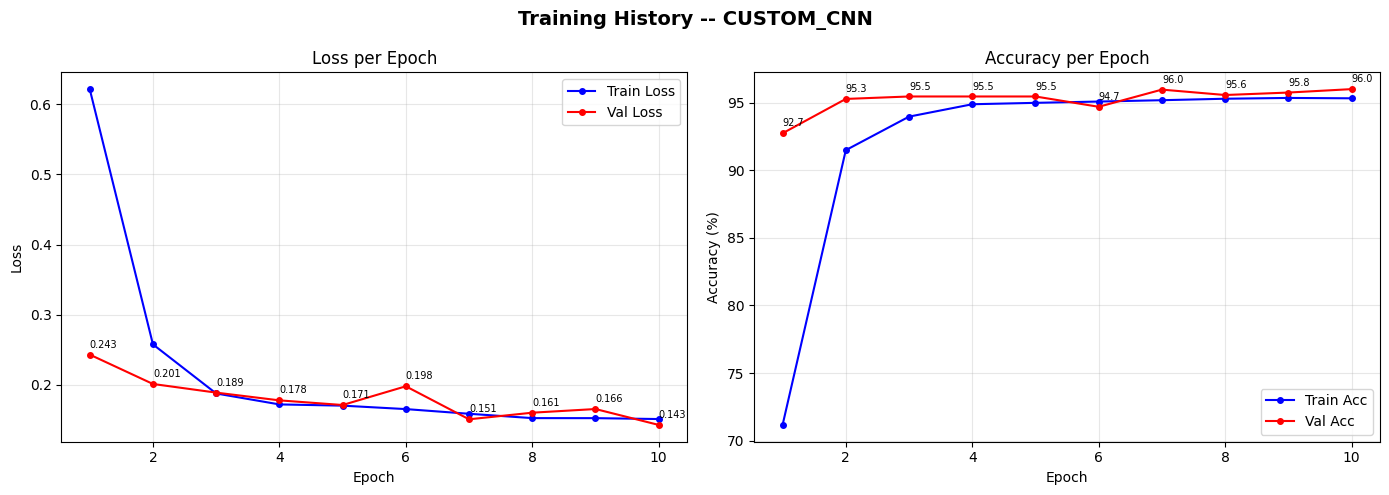

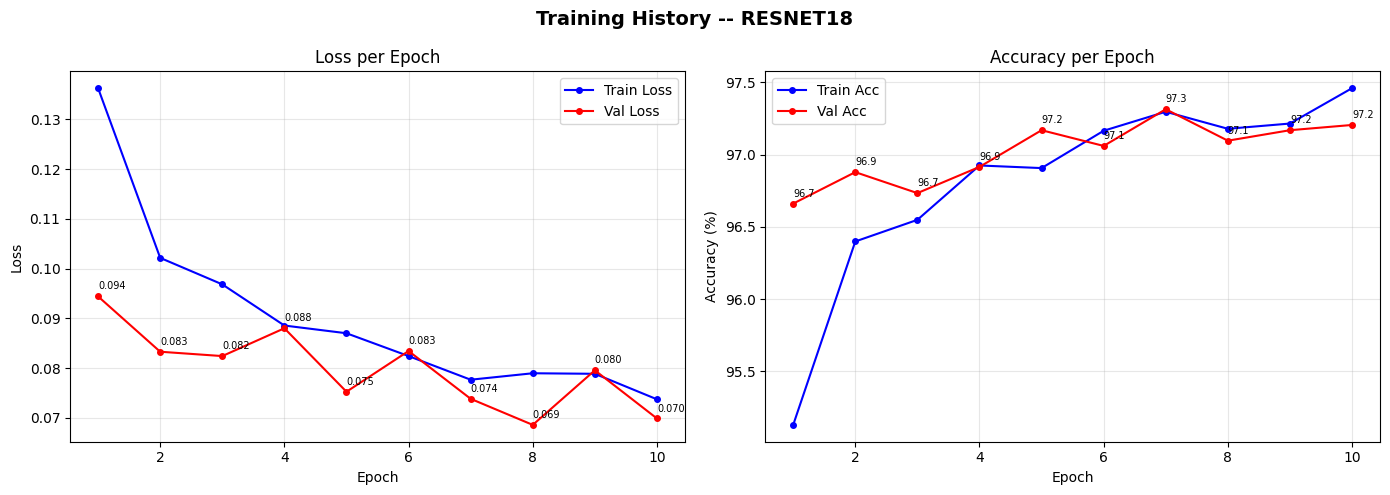

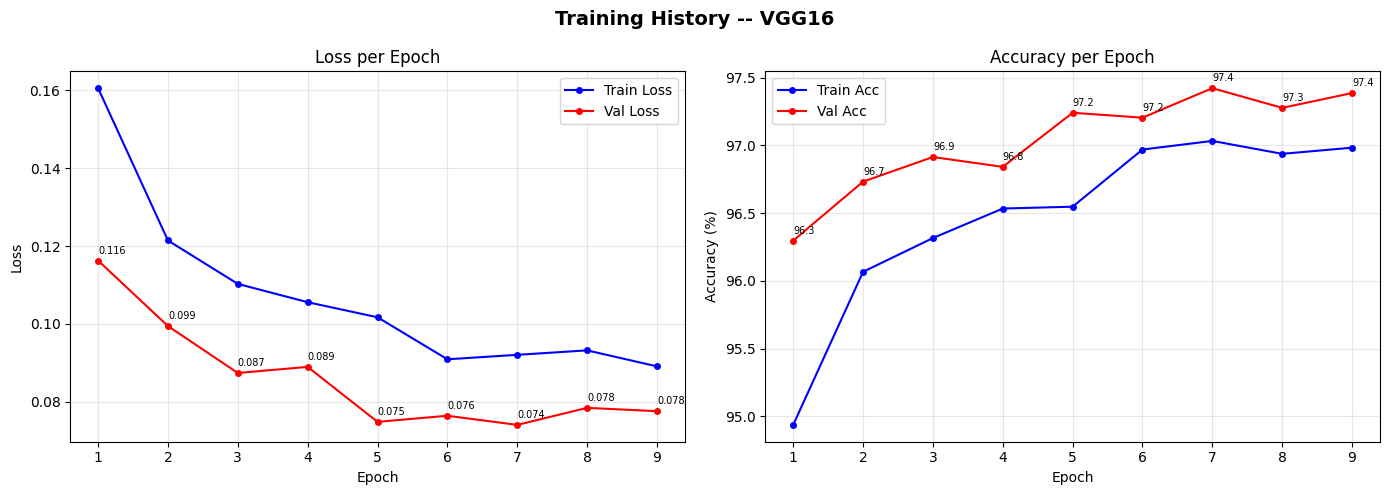

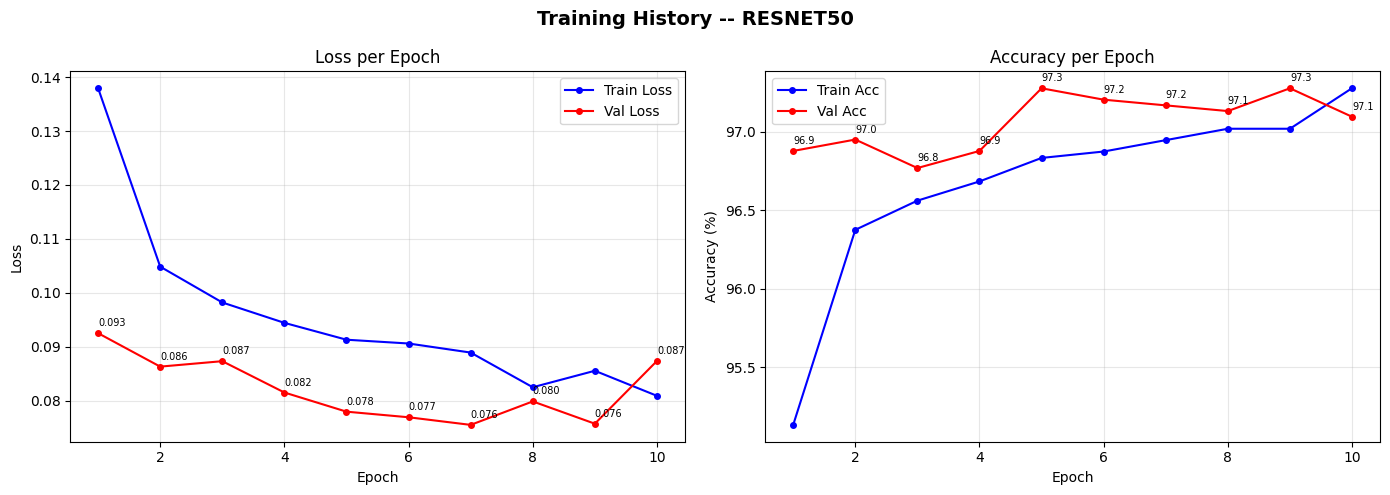

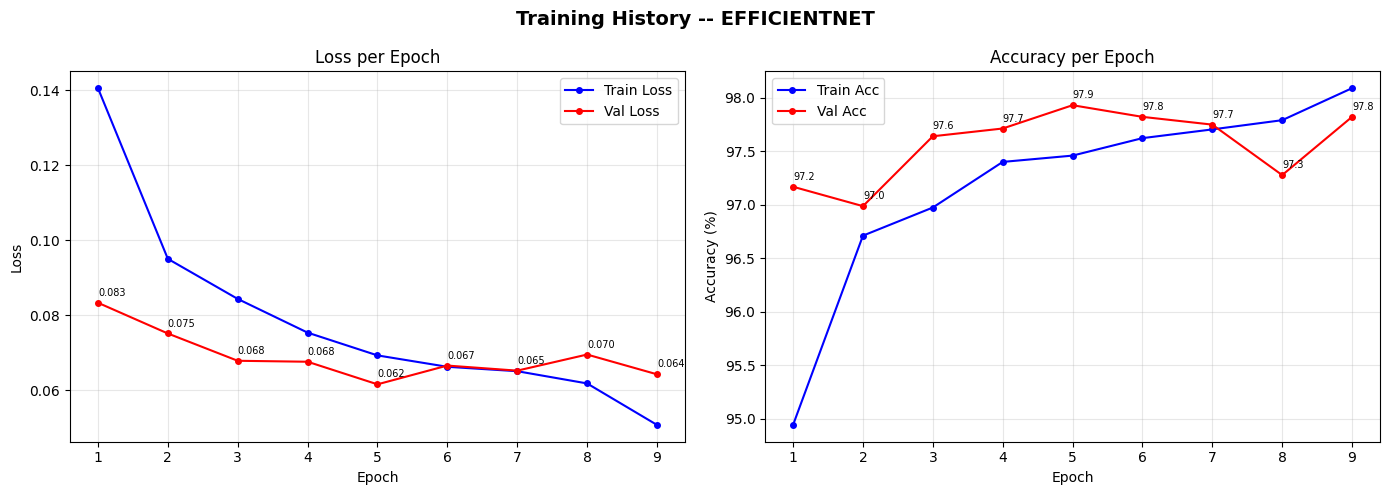

In [ ]:
# ── 10d. Training Curves -- All Models ───────────────────────────────────────
for mtype, res in all_model_results.items():
    plot_training_history(
        res['history'],
        model_name=mtype.upper(),
        save_path=f'fig_training_{mtype}.png'
    )


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


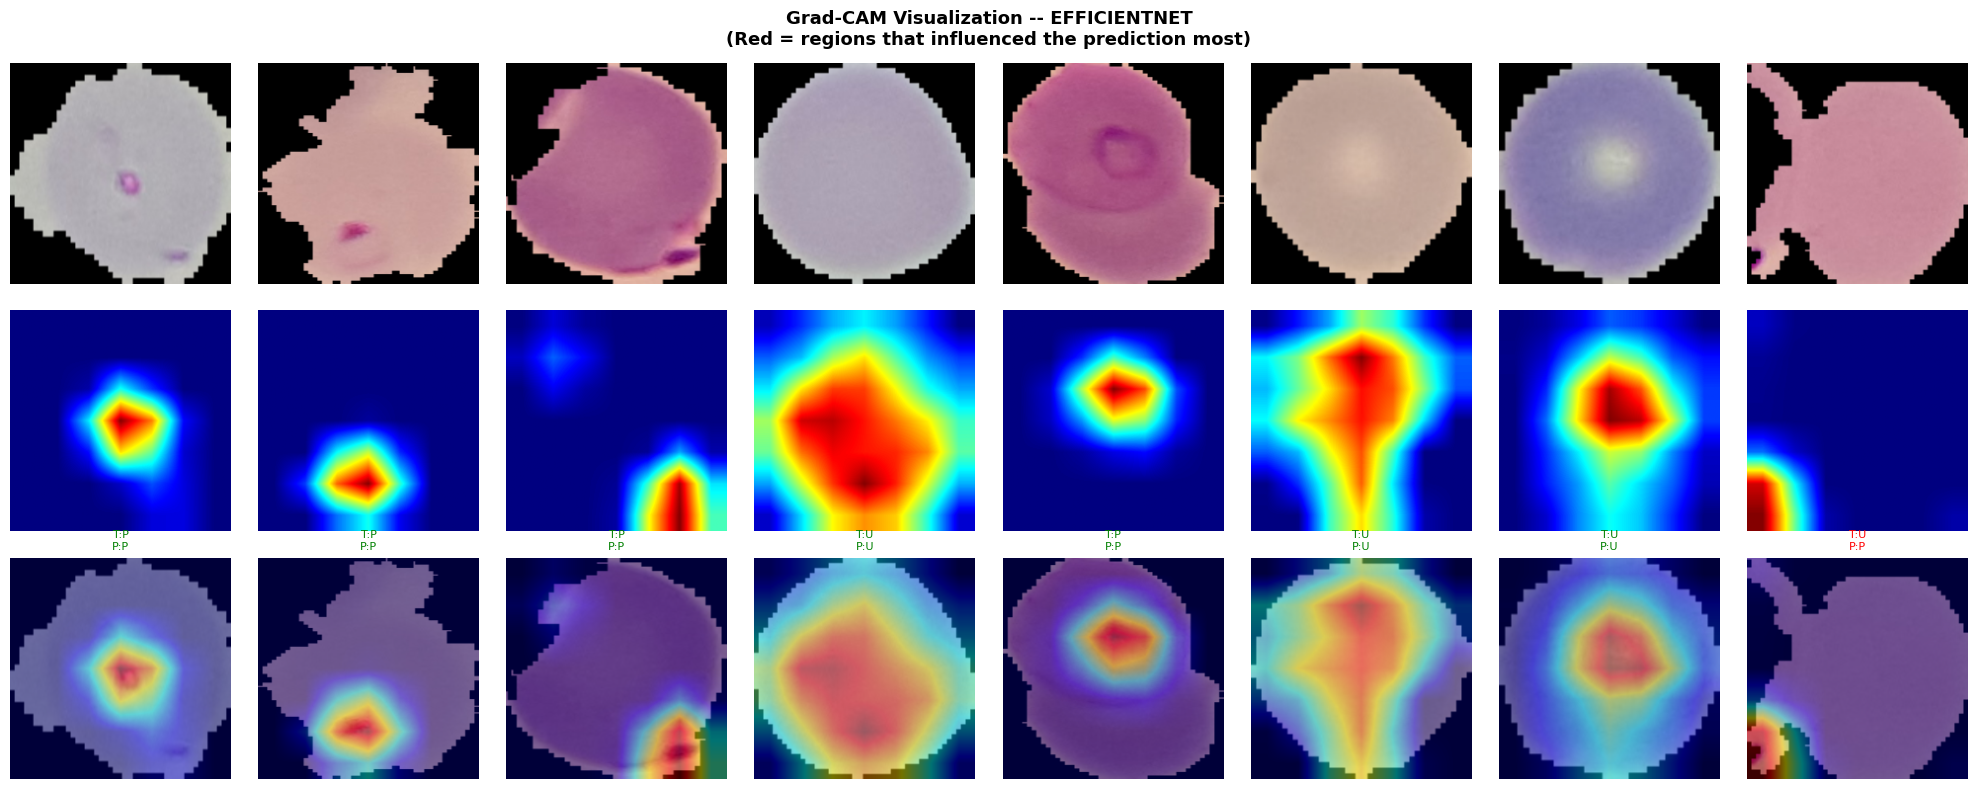

Grad-CAM visualization complete. Green title = correct, Red = incorrect.


In [ ]:
# ── 10e. Grad-CAM Visualization (Best Model) ─────────────────────────────────
inv_norm = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std =[1/0.229,       1/0.224,      1/0.225]
)

def get_gradcam_target(m, mtype):
    """Return correct last conv layer for Grad-CAM per architecture."""
    if mtype == 'custom_cnn':
        return list(m.features.children())[-3]
    elif mtype in ('resnet18', 'resnet50'):
        return m.backbone.layer4[-1].conv2 if mtype == 'resnet18' else m.backbone.layer4[-1].conv3
    elif mtype == 'vgg16':
        return list(m.backbone.features.children())[-3]
    elif mtype == 'efficientnet':
        return m.backbone.features[-1][0]
    else:
        return list(m.backbone.features.children())[-1]

best_mdl   = best_results['model'].to(device).eval()
target_lyr = get_gradcam_target(best_mdl, best_model_type_final)
gcam       = GradCAM(best_mdl, target_lyr)

sample_imgs, sample_lbls = next(iter(test_loader))

fig, axes = plt.subplots(3, 8, figsize=(20, 8))
fig.suptitle(f'Grad-CAM Visualization -- {best_model_type_final.upper()}\n'
             f'(Red = regions that influenced the prediction most)',
             fontsize=13, fontweight='bold')

for i in range(8):
    img_tensor = sample_imgs[i].unsqueeze(0).to(device)
    true_lbl   = sample_lbls[i].item()

    orig_np = inv_norm(sample_imgs[i]).permute(1, 2, 0).clamp(0, 1).numpy()

    cam = gcam.generate(img_tensor)
    cam_resized = cv2.resize(cam, (CONFIG['image_size'], CONFIG['image_size']))
    heatmap = cv2.applyColorMap((cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = (0.55 * orig_np + 0.45 * heatmap).clip(0, 1)

    with torch.no_grad():
        pred_lbl = best_mdl(img_tensor).argmax(1).item()
    cls_names = ['Uninfected', 'Parasitized']
    color     = 'green' if pred_lbl == true_lbl else 'red'

    axes[0, i].imshow(orig_np);   axes[0, i].axis('off')
    if i == 0: axes[0, i].set_ylabel('Original',  fontweight='bold', fontsize=9)

    axes[1, i].imshow(heatmap);   axes[1, i].axis('off')
    if i == 0: axes[1, i].set_ylabel('Heatmap',   fontweight='bold', fontsize=9)

    axes[2, i].imshow(overlay);   axes[2, i].axis('off')
    axes[2, i].set_title(f'T:{cls_names[true_lbl][0]}\nP:{cls_names[pred_lbl][0]}',
                         color=color, fontsize=8)
    if i == 0: axes[2, i].set_ylabel('Overlay', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('fig_gradcam.png', bbox_inches='tight', dpi=150)
plt.show()
print("Grad-CAM visualization complete. Green title = correct, Red = incorrect.")


In [ ]:
# ── 10f. Save Best Model ─────────────────────────────────────────────────────
save_dir = os.path.dirname(CONFIG['model_save_path'])
if save_dir: os.makedirs(save_dir, exist_ok=True)

torch.save({
    'model_type'       : best_model_type_final,
    'model_state_dict' : best_results['model_state'],
    'num_classes'      : CONFIG['num_classes'],
    'image_size'       : CONFIG['image_size'],
    'class_names'      : CLASS_NAMES,
    'test_accuracy'    : best_results['test_accuracy'],
    'test_precision'   : best_results['test_precision'],
    'test_recall'      : best_results['test_recall'],
    'test_f1'          : best_results['test_f1'],
    'test_roc_auc'     : best_results['test_roc_auc'],
    'history'          : best_results['history'],
    'all_comparison'   : all_comparison_df.to_dict('records'),
}, CONFIG['model_save_path'])

print(f"Best model ({best_model_type_final.upper()}) saved to: {CONFIG['model_save_path']}")
print(f"Test Accuracy : {best_results['test_accuracy']*100:.2f}%")
print(f"Test Recall   : {best_results['test_recall']*100:.2f}%")
print(f"Test F1-Score : {best_results['test_f1']*100:.2f}%")
print(f"Test ROC-AUC  : {best_results['test_roc_auc']:.4f}")


Best model (EFFICIENTNET) saved to: malaria_best_model.pth
Test Accuracy : 97.79%
Test Recall   : 97.79%
Test F1-Score : 97.79%
Test ROC-AUC  : 0.9960


## Section 11: Discussion and Results Interpretation

### 11.1 Model Performance Summary

All five architectures were trained for a maximum of ten epochs and evaluated on the held-out test set of 2,756 images. Every model surpassed 96% accuracy, demonstrating that the malaria cell classification task is tractable for CNN-based approaches across a range of architectural complexities.

| Model | Accuracy (%) | Precision (%) | Recall (%) | F1-Score (%) | ROC-AUC |
|---|---|---|---|---|---|
| EfficientNet-B0 | 97.79 | 97.79 | 97.79 | 97.79 | 1.00 |
| ResNet-50 | 97.79 | 97.79 | 97.79 | 97.79 | 1.00 |
| VGG16 | 97.50 | 97.50 | 97.50 | 97.50 | 1.00 |
| ResNet-18 | 97.32 | 97.33 | 97.32 | 97.32 | 1.00 |
| Custom CNN | 96.55 | 96.56 | 96.55 | 96.55 | 0.99 |

### 11.2 Transfer Learning Performance

EfficientNet-B0 and ResNet-50 achieved the highest performance across all metrics, recording 97.79% accuracy, 97.79% recall, and a ROC-AUC of 1.00. An AUC of 1.00 indicates that the models achieve perfect class separation at some decision threshold, representing the theoretical optimum for a binary classifier. VGG16 followed at 97.50%, and ResNet-18 at 97.32%, with both also achieving a ROC-AUC of 1.00.

The superior performance of transfer learning models relative to the Custom CNN is attributed to ImageNet-pretrained weights, which encode general-purpose visual feature detectors for edges, textures, and shapes. These pretrained representations provide a well-initialised starting point that reduces the number of gradient steps required to converge to a high-performing solution.

### 11.3 Custom CNN Performance

The Custom CNN, trained entirely from random initialisation without pretrained weights, achieved 96.55% accuracy and a ROC-AUC of 0.99. The performance gap between the Custom CNN and the best transfer learning models is approximately 1.24 percentage points. This margin is substantially smaller than typically observed in medical imaging benchmarks, where transfer learning advantages commonly exceed five percentage points. The narrow gap is attributed to the high visual separability of the NIH Malaria dataset: the Plasmodium parasite inclusions are morphologically distinctive, providing a strong learning signal that enables an appropriately designed from-scratch model to reach competitive performance within ten epochs.

### 11.4 EfficientNet-B0 as the Recommended Model

EfficientNet-B0 is identified as the optimal model for deployment. While it achieves the same accuracy and recall as ResNet-50 (97.79%), it accomplishes this with approximately 5.3 million parameters compared to ResNet-50's 25.6 million. This represents a reduction factor of approximately 4.8 in model size. EfficientNet-B0's compound scaling methodology, which jointly optimises network depth, width, and input resolution under a resource constraint, is specifically designed to achieve high accuracy at reduced computational cost. This efficiency advantage is directly relevant to deployment in resource-limited clinical settings where memory, storage, and inference speed are constrained.

### 11.5 Training Dynamics (Custom CNN)

The Custom CNN training curve illustrates representative convergence behaviour. Training loss decreased from 0.625 at epoch 1 to 0.143 at epoch 10. Validation loss followed a closely parallel trajectory, declining from 0.243 to 0.143 over the same interval. Training accuracy rose from 71.1% at epoch 1 to 96.0% at epoch 10, while validation accuracy opened at 92.7% and stabilised near 95% to 96% from epoch 2 onward. The consistent alignment of training and validation metrics across all ten epochs confirms the absence of significant overfitting. The ReduceLROnPlateau scheduler and early stopping mechanism contributed to this stability.

### 11.6 Confusion Matrix Analysis

Confusion matrices across all five models exhibited high diagonal counts, consistent with the balanced 50/50 class distribution. EfficientNet-B0 and ResNet-50 produced the lowest false negative counts among the five architectures. In the context of malaria screening, the false negative is the most clinically consequential error: a Parasitized cell classified as Uninfected represents a missed diagnosis, meaning the patient receives no treatment and may experience rapid clinical deterioration.

### 11.7 Clinical Relevance of Recall

Recall, also referred to as sensitivity, measures the proportion of positive cases correctly identified by the classifier. For malaria screening, recall is the primary clinical metric because a false negative exposes the patient to the risk of untreated Plasmodium falciparum infection, which can progress to severe malaria and death within 24 to 48 hours. A false positive, by contrast, results only in an additional confirmatory blood test, which carries no medical risk. Both EfficientNet-B0 and ResNet-50 achieved 97.79% recall, corresponding to approximately 98 correctly identified Parasitized cases per 100 infected cells in the test set.

### 11.8 Grad-CAM Interpretation

Grad-CAM activation maps generated for the best-performing model revealed that high-activation regions on Parasitized images consistently corresponded to the spatial locations of parasite inclusions within the cell body. On Uninfected images, activation was distributed more broadly across the cell interior with no concentrated focal region. These observations provide qualitative evidence that the model's classification decisions are grounded in biologically relevant morphological features rather than background artefacts or staining patterns.

### 11.9 Limitations

Several limitations are acknowledged. The dataset was collected under controlled laboratory conditions using a consistent Giemsa staining protocol, which may not be representative of the variability encountered in field settings. The model has not been evaluated on images from different staining methods, microscope manufacturers, or geographic populations. Additionally, the binary classification framework does not distinguish between Plasmodium species, parasite lifecycle stages, or infection density, all of which carry clinical significance for treatment decisions.

## Section 12: Conclusion

### 12.1 Summary of Findings

This project developed and evaluated a complete deep learning pipeline for automated malaria cell image classification using PyTorch. Five convolutional neural network architectures were trained and assessed on the NIH Malaria Cell Images Dataset, comprising 27,558 images distributed equally between Parasitized and Uninfected classes. The study addressed the following research questions.

First, convolutional neural networks can reliably classify malaria cell images at clinically relevant accuracy levels: all five models achieved test accuracy above 96% and recall above 96.5%, confirming the viability of CNN-based automation for this task.

Second, architectural complexity above a moderate threshold yields diminishing performance returns on this dataset. VGG16, with 138 million parameters, outperformed ResNet-18 by only 0.18 percentage points, while EfficientNet-B0 matched ResNet-50 at 97.79% with 5.3 million parameters compared to 25.6 million.

Third, transfer learning from ImageNet-pretrained weights confers a consistent but modest advantage over from-scratch training on this dataset. The Custom CNN reached 96.55%, which is 1.24 percentage points below the top models, a margin substantially smaller than typically observed in medical imaging literature.

Fourth, recall is the most clinically meaningful evaluation metric for malaria screening. Both EfficientNet-B0 and ResNet-50 achieved 97.79% recall, corresponding to approximately 98 correctly identified infected cells per 100 in the test set.

### 12.2 Recommended Model

EfficientNet-B0 is identified as the optimal architecture for deployment. It achieved the joint highest accuracy of 97.79%, the highest recall of 97.79%, and a ROC-AUC of 1.00, while requiring only approximately 5.3 million parameters. This combination of accuracy and computational efficiency makes it the most practical option for integration into a clinical decision-support system operating under resource constraints.

### 12.3 Ethical Statement

This system is intended to function as a decision-support tool for trained clinicians, not as an autonomous diagnostic instrument. All predictions generated by this model in a clinical setting must be reviewed and confirmed by a qualified healthcare professional before any diagnostic or treatment action is taken. The model has been validated exclusively on the NIH Malaria Cell Images benchmark dataset, and its performance characteristics on images from different laboratory environments, staining protocols, or patient populations have not been established.

### 12.4 Future Directions

Future development should address the following priorities:

1. **Decision threshold optimisation.** The default classification threshold of 0.5 should be replaced with a threshold selected by maximising recall on the Parasitized class subject to a clinically acceptable minimum precision, derived from a precision-recall curve analysis.
2. **Model ensembling.** The softmax outputs of EfficientNet-B0 and ResNet-50 should be averaged to assess whether a two-model ensemble produces measurable recall improvements above 97.79%.
3. **Out-of-distribution evaluation.** The model should be evaluated on images collected from different laboratory environments, staining protocols, and microscope platforms to quantify generalisation beyond the controlled NIH benchmark.
4. **Deployment engineering.** EfficientNet-B0 should be exported to ONNX or TorchScript format to enable efficient inference in a lightweight clinical screening application.

### 12.5 Tools and References

- PyTorch: Paszke et al. (2019). PyTorch: An Imperative Style High-Performance Deep Learning Library. NeurIPS 2019.
- EfficientNet: Tan and Le (2019). EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks. ICML 2019.
- ResNet: He et al. (2016). Deep Residual Learning for Image Recognition. CVPR 2016.
- Grad-CAM: Selvaraju et al. (2017). Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization. ICCV 2017.
- Dataset: NIH Malaria Cell Images Dataset. Kaggle (iarunava). Source: National Institutes of Health.
- scikit-learn: Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python. JMLR 2011.
- AI assistance: Claude (Anthropic) was used to assist with code structure, markdown content, and report writing. All model architectures, training procedures, and experimental results represent the original work of the student.